In [1]:
from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
from modules.img_processing import DITHER_MODES
from modules.palette_generator import get_asciis, make_1d_bin_palette, make_2d_bin_palette
from modules.print_gallery import print_gallery
from modules.img2chars_mono_1d import img2char_arr_1d
from modules.img2chars_mono_2d import img2char_arr_2d
from modules.ansi_colorizer import AnsiColorizer

In [2]:
ASCII_SET = get_asciis()
FONT = ImageFont.truetype("../fonts/CascadiaMono.ttf", 11)
IMG_PATH = "../imgs/rgb_grad.png"
IMG_SIZE = (32, 32)

In [3]:
two_char_symbols_set = []
for a in ASCII_SET:
    for b in ASCII_SET:
        two_char_symbols_set.append(a + b)

In [4]:
img = Image.open(IMG_PATH)
img.thumbnail(IMG_SIZE)

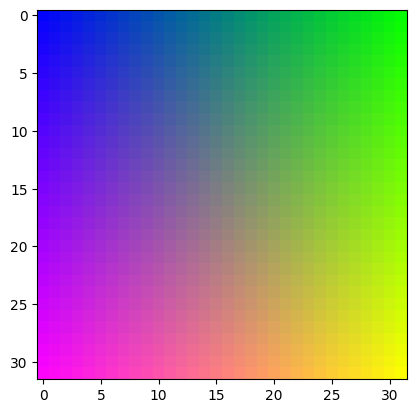

In [5]:
plt.imshow(img, interpolation='none')

In [6]:
colorize_settings = AnsiColorizer(
    colored_fg=True,
    colored_bg=False,
    use_ansi_256_colors=True)

bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

doubled_palette, doubled_palette_brs = make_1d_bin_palette(
    symbols=two_char_symbols_set,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    ansi_colorizer=colorize_settings))

results.append(img2char_arr_1d(
    img=ImageOps.scale(img, 0.5),
    bin_palette=doubled_palette,
    bin_vals=doubled_palette_brs,
    scale_vertically=False,
    ansi_colorizer=colorize_settings))

print_gallery(results)

---------------------------------------------------------------------------
 | @Q$@BEEGmPpjn{IVn7ou}b4pm5bM@BMQ | QMQ@Q@Mh(@hzTy1diA{fUsEH5$M@WWW$ | 
 | B$WW@PU%wAw}yFIFJjfay6UP9GGNBNQQ | QMWMW$UGSg/54[%|ujbfYIQeNaWNQWM@ | 
 | @W$WWAwAG5pIntI7j{]uF6OqKHHBBQMQ | NWW$WM$2uBT7Se/GjV7{G(#HO%N@@NW$ | 
 | QBBBBbKOK5m{s{uFVCn[{KmOEU9BBNNB | M@BW@Wpd&KuJ3jk)CICjEz$kgP@MMM@M | 
 | M$BBQpKmm%Go7uJj3nosuOp6OpdMQNBM | MWWWWQMqXB7FJ[{{j[]ePYBKMfWQ@$@N | 
 | BQWWN4dpdb%ff]Fef]ee7H%KUE5BBW@W | WB$@M@&eG6hzU}lAkj}Vg+qp4gWM$@B@ | 
 | @NWQ$ppbdwG{e72}Z]2}[GAdKqdBB$W$ | NW$@W@q#8U3[{38LP+stElVQE&@$W$WM | 
 | QWWWNqPGAG9[3eoJfVVtI5UdqpdMMNMQ | MMWN$@WZKOkx&!=$O>ea3op0dR@NW@@B | 
 | N$$@B9b9EPEynCVutnoVVKpq5OPWMMWW | QW@NW@sMP8hyJ{/9<RTGI1NXMuQ@QWWQ | 
 | NNWN$9GOwHGns2yfjC{73A%HH6KQN@W@ | WMWQQWN7B4jeHLo{*UPis]UQ$UMMQMWB | 
 | Q@$NM9qAE54sC}oy3fauCdmw%G6W$QWW | WNB@WMWFDm@;r3[CvpuS"@Dh&G@QW@QM | 
 | @BQMBUwAbPEO4Apm4d5%6%9qq%pBMNMQ | MQW@WNRKIN#0Rb$]GPHKpb%0&4Q@MM@B | 
 | NMMQQ99KEHPO64A6dwm4G%6%HPwWQMWB 

In [7]:
bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    dither=DITHER_MODES.NONE,
    ansi_colorizer=colorize_settings))

results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    dither=DITHER_MODES.BAYER,
    ansi_colorizer=colorize_settings))

results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    dither=DITHER_MODES.JJN,
    ansi_colorizer=colorize_settings))

print_gallery(results, 3)

---------------------------------------------------------------------------------------------------------------
 | NWWBNbO5UUw[3JZCeZJaaPEE49KBM@@B | QMN$bBEN)b(RijLJ>Fx#zp1Db$qW%@@@ | W$@NNw5A4qs{fn3uaJJ{u%%KmbHBM@@W | 
 | WQNWN5Ebb9PC3C7VsII}JApdPUAM@$W@ | $NBW$dMqbY%CseJFIvsFI1Abb9@QM@$N | QNQ&O%dpK%o[jy127Yuj]CGp46AKB$QB | 
 | $M@MM5%GAbq]fa3onty7J9AmEpqM@$NM | QQ$BwMGUm%)pzF=o=aYyY8rmANdWWW@M | $NW#RPgHbZemfIfn}FLI2Js4UR0#DQB$ | 
 | MNNMBOKA4%qo]}{}Juo{FPpmG65$Q@@N | B$@WM56q9443tnV+Fafu4oUPEbBWB$W@ | M$@@0PED5a32Tu[>1/sClPOt4bbMDWBB | 
 | QQ$WNmwpOAPeCII{{jZ235wAKPpB$@NB | WNBQPM%NYwL8x}TF>al&vEz#PB4MGWQW | B$WD&Kq5bO]2{)y}Vn]s[eUbGb%9WDBB | 
 | MNQNB%bpP%HnnCtjF7VCaKmpbmq@@$@B | Q$NWBA$POGPee1JoV13Iuv64OA$$NQNN | Q$WRM4g96[E7oZj1C7i{uId5R&A#NQ$Q | 
 | QQMMQOEUppUj[2FC2Vt[J4m5PGH@M$Q@ | WNB$wNUq5Dlw)f=y>JLb1wlPwNmN$WQ@ | $Q8BRUG05CuVVsaZ>3Cxt2G}POw&&$BW | 
 | @QQ$@549O6AoFeF[7y{I{KGmHwbNNWBN | MBBNN9qOmmm22{3=Cty}%3Op4EQ@MBQQ | B$@ggK4p5djjYZZL>un7}p}Hw6d%@gNW | 
 | MM@M$wOq%UE2F

In [8]:
bins = 12
palette, palette_brs = make_1d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results = []
results.append(img2char_arr_1d(
    img=img,
    bin_palette=palette,
    bin_vals=palette_brs,
    ansi_colorizer=colorize_settings))

bins = (9, 9)
palette, palette_brs = make_2d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results.append(img2char_arr_2d(img, palette, ansi_colorizer=colorize_settings))

print_gallery(results)

---------------------------------------------------------------------------
 | QB$$MbqKGdpCoeF{[sFosEdOOPO@W@BW | @@@@@@@@@@@Uh4XhXUShX@@@@@@@@@@@ | 
 | QQWWMAEP5GO}sZf[Zf7[fEp59UP$NBWW | @@@@@@@@@@@S4Uh44ShSX@@@@@@@@@@@ | 
 | Q@@NNObpGE6fIoeau{22[9mAAdmN$@MN | @@@@@@@@@@@U4UShUSXUS@@@@@@@@@@@ | 
 | W@N@Wpw5wG6sZJuFF7fuCpp%9ObM@MQN | @@@@@@@@@@@SXS4XhX4X4@@@@@@@@@@@ | 
 | MBNMNOpqKHOFtjCfI{su{dH%HEO$$QN$ | @@@@@@@@@@@4SS4UhUSS4@@@@@@@@@@@ | 
 | $@MMBOpdbO%7f{tI2Js]C9p5bwOBBNBM | @@@@@@@@@@@UXUhU4hUXU@@@@@@@@@@@ | 
 | BWNNQP%Kw%5eCJ]etI]CZppAU6qN@NW$ | @@@@@@@@@@@UU4XX4S4Uh@@@@@@@@@@@ | 
 | N$$@NGOqpOOC}Vuu7Z7aoPKAbGH$B@N$ | @@@@@@@@@@@U4S4SSSUX4@@@@@@@@@@@ | 
 | WNQBBUGP9EOF]2sZI}jufdEpOHKMBQ@$ | @@@@@@@@@@@S44hUhhhUX@@@@@@@@@@@ | 
 | NNMN@4O54O57]Cts}ftJFAbpm6q@MMBB | @@@@@@@@@@@hXhXhh4XhX@@@@@@@@@@@ | 
 | Q@BNBmA%pOPJ{}tFj}u[eHG5mUmQWW$W | @@@@@@@@@@@KKKKKKKKKK@@@@@@@@@@@ | 
 | $@QW$9qbHKUwOO%Odd%P65KApE4MW$MB | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@ | 
 | @$NQQGUU5A69pU%md9GUKO9bbqH$$WNN 

In [9]:
results = []

bins = (9, 9)
palette, palette_brs = make_2d_bin_palette(
    symbols=ASCII_SET,
    font=FONT,
    bins=bins,
    normalize=True)

results.append(img2char_arr_2d(img, palette, dither=DITHER_MODES.NONE, ansi_colorizer=colorize_settings))
results.append(img2char_arr_2d(img, palette, dither=DITHER_MODES.BAYER, ansi_colorizer=colorize_settings))
results.append(img2char_arr_2d(img, palette, dither=DITHER_MODES.JJN, ansi_colorizer=colorize_settings))

print_gallery(results, 3)

---------------------------------------------------------------------------------------------------------------
 | @@@@@@@@@@@4UhUUX4SUS@@@@@@@@@@@ | @@@@WMW@wOKO2h44oX4O2OK@WMW@W@@@ | @@@@M$RRWRhUUXXSUSSXXV$BQ$R@@@@@ | 
 | @@@@@@@@@@@UUS4ShhXSh@@@@@@@@@@@ | @@@@W@W@W@GOXSftnU24KOK@W@W@@@@@ | @@@@NW$W#XUVUX2t4(XVhAKO#@DW$@@@ | 
 | @@@@@@@@@@@U4Uh44XhXU@@@@@@@@@@@ | @@@@WMW@GRKO2hhUJhUO2OK@QMW@W@@@ | @@@QWQRD@OKh4Z2UXFS43U8WBDR@@W@@ | 
 | @@@@@@@@@@@UXhSSSU4U4@@@@@@@@@@@ | @@@@W@Q@W@KOUUstfX2OKOm@Q@W@@@@@ | @@@M8@Q8WESVSXZX\UVhU6PA@Q8#@M@@ | 
 | @@@@@@@@@@@XUSX4SUSXX@@@@@@@@@@@ | @@@@W@W@mOKO2USho44O2OK@WMW@W@@@ | @@@N@D0@5S0U4ZSXZtX24h0QDRQ@M@@@ | 
 | @@@@@@@@@@@SSh4hUS44X@@@@@@@@@@@ | @@@@W@W@Q@GOSXotfS2hKOK@Q@W@@@@@ | @@@W@QDWR5S4U2h4oUFhS8KXNQ8$@M@@ | 
 | @@@@@@@@@@@USS4hUXhS4@@@@@@@@@@@ | @@@@WMW@mBKO2USXsXUO2OK@WMW@W@@@ | @@@DMQ$8WdP2SSCtU(UUVSQ#NWBW@@@@ | 
 | @@@@@@@@@@@SXUXUUSU44@@@@@@@@@@@ | @@@@W@W@W@GOhSntnXUOKOw@Q@W@@@@@ | @@@@N0WBN4AFSUUXZXS34KOb@0QW@Q@@ | 
 | @@@@@@@@@@@hh